In [1]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import maglab.formats.mumax3 as mx3
import maglab.analysis.ringdown as rd
import maglab.loaders.ringdown as l_rd
import maglab.loaders.utils as l_ut

In [ ]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"
table = mx3.read_table(TABLE_PATH)
# table.loc[0, ["mx ()", "my ()", "mz ()"]].to_numpy()
# table.loc[:, table.columns.str.contains("mx|my|mz")]
# table.loc[0, table.columns.str.contains("B_extx|B_exty|B_extz")]
l_ut.compute_dot_vectors(table, ["m", "B_ext"], direction="B_ext")
# table

m
B_ext


[array([0.5855387, 0.5855387, 0.5855385, ..., 0.5855368, 0.5855368,
        0.5855368], shape=(1001,)),
 array([0.04000051, 0.04000051, 0.04000051, ..., 0.04000051, 0.04000051,
        0.04000051], shape=(1001,))]

(0.0, 18.0)

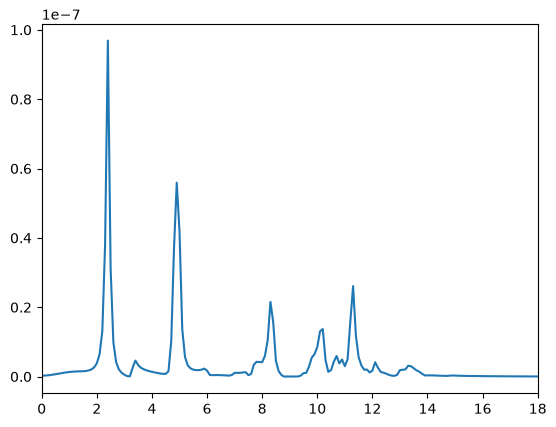

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"

df = l_rd.load_mag_avg_ringdown(TABLE_PATH)
plt.plot(df["frequency"], df["absorption"])
plt.xlim(0, 18)

Loading OVF files: 100%|██████████| 1201/1201 [00:01<00:00, 933.73 files/s]


(0.0, 20.0)

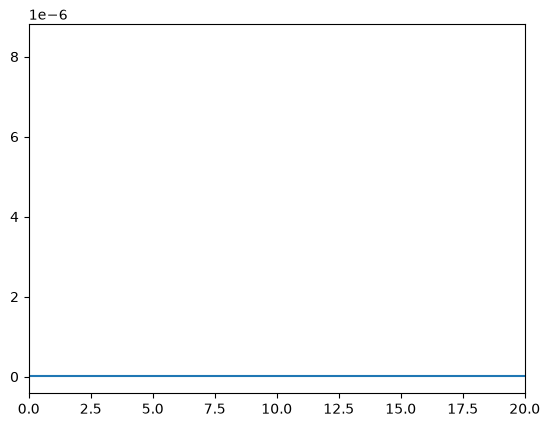

In [43]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-22 AASI Dynamics 2x2\1-1\1-1_phi0_3\1-1_phi0_3exct_B000060.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out")
# (psd, phase), (frequencies, psd_spectrum) = l_rd.load_ringdown(DIRPATH)
# plt.plot(frequencies, psd_spectrum)

spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

(0.0, 3e-07)

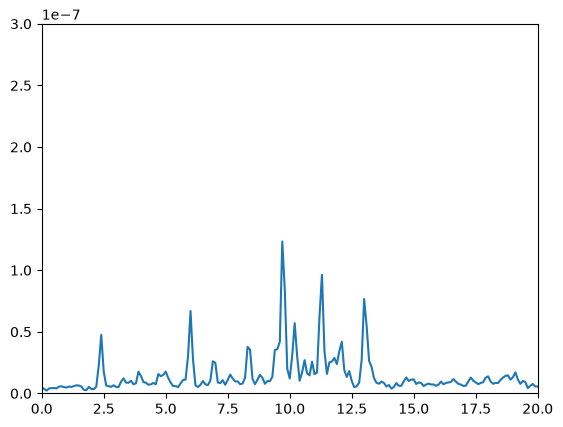

In [47]:
plt.plot(freqs / 1e9, bls)
plt.xlim(0, 20)
plt.ylim(0, 0.3e-6)

In [ ]:

f_idx = 24
s = spec[f_idx].mean(axis=0)                    # average over z
s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
v = np.abs(s.real).max()
plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)

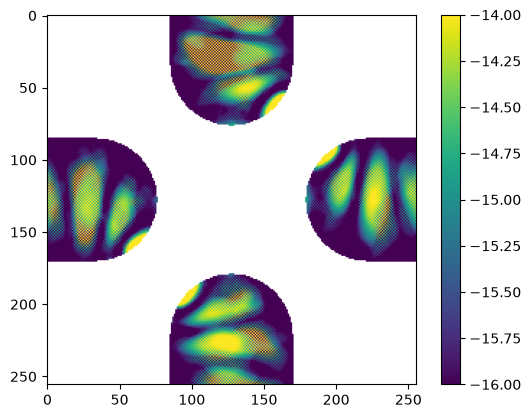

In [40]:
plt.imshow(np.log(psd[46, 4, ...]), clim=(-16, -14))
plt.colorbar()